# Phase 0 — Corpus overview

Political-compass position and chunk distribution across the seven corpora.
All chunks are from `scored_chunks.jsonl`; retained subset (conf_margin ≥ 0.015) is in `retained.jsonl`.

In [1]:
import json
import random
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

plt.rcParams.update({
    "font.family":       "serif",
    "font.size":         11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

BASE      = Path("../data/experts/quadrant-pools")
SOURCES   = ["allsides", "ec_press", "ire_press", "uk_press", "hoc", "reddit_liberal", "reddit_conservative", "us_media", "us_speeches"]
QUADRANTS = ["right_auth", "left_auth", "left_lib", "right_lib"]

Q_LABEL = {
    "right_auth": "Q1 (right_auth)",
    "left_auth":  "Q2 (left_auth)",
    "left_lib":   "Q3 (left_lib)",
    "right_lib":  "Q4 (right_lib)",
}
Q_SHORT = {
    "right_auth": "Q1",
    "left_auth":  "Q2",
    "left_lib":   "Q3",
    "right_lib":  "Q4",
}
COLORS = {
    "right_auth": "#e17a7a",
    "left_auth":  "#9dc5e2",
    "left_lib":   "#aee8bf",
    "right_lib":  "#fbf09e",
}
SOURCE_LABEL = {
    "allsides":            "AllSides",
    "ec_press":            "EC Press Releases",
    "ire_press":           "Irish Gov. Press Releases",
    "uk_press":            "UK Gov. Press Releases",
    "hoc":                 "UK House of Commons",
    "reddit_liberal":      "Reddit (Liberal)",
    "reddit_conservative": "Reddit (Conservative)",
    "us_media":            "US News Media",
    "us_speeches":         "US Presidential Speeches",
}
FAMILY = {
    "reddit_liberal":      "Reddit",
    "reddit_conservative": "Reddit",
    "allsides":            "Press",
    "ec_press":            "Press",
    "ire_press":           "Press",
    "uk_press":            "Press",
    "us_media":            "Press",
    "hoc":                 "Speeches",
    "us_speeches":         "Speeches",
}
FAMILY_STYLE = {
    "Reddit":   {"color": "#e6194b", "marker": "o", "alpha": 0.25, "zorder": 3},
    "Press":    {"color": "#3cb44b", "marker": "s", "alpha": 0.25, "zorder": 2},
    "Speeches": {"color": "#4363d8", "marker": "^", "alpha": 0.35, "zorder": 4},
}

## Mean ideological position per source × quadrant

Each bubble = one source × quadrant cell. Position = mean (econ, soc) score of all chunks; area ∝ chunk count.

In [2]:
records = []

for source in SOURCES:
    path = BASE / source / "scored_chunks.jsonl"
    if not path.exists():
        print(f"[skip] {source}: scored_chunks.jsonl not found (batch not yet run?)")
        continue
    buckets = defaultdict(lambda: {"econ": [], "soc": [], "abs_econ": [], "abs_soc": [], "conf": []})
    with open(path) as f:
        for line in f:
            d = json.loads(line)
            q = d["quadrant"]
            ae, as_ = d["score_abs_econ"], d["score_abs_soc"]
            if ae == ae:   buckets[q]["abs_econ"].append(ae)
            if as_ == as_: buckets[q]["abs_soc"].append(as_)
            e, s = d["score_econ"], d["score_soc"]
            if e == e: buckets[q]["econ"].append(e)
            if s == s: buckets[q]["soc"].append(s)
            c = d["confidence_margin"]
            if c == c: buckets[q]["conf"].append(c)

    total = sum(len(v["econ"]) for v in buckets.values())
    for q in QUADRANTS:
        b = buckets[q]
        n = len(b["econ"])
        records.append({
            "source":        source,
            "quadrant":      q,
            "n_chunks":      n,
            "pct_of_source": 100 * n / total if total else 0,
            "mean_econ":     float(np.mean(b["econ"]))     if b["econ"]     else float("nan"),
            "mean_soc":      float(np.mean(b["soc"]))      if b["soc"]      else float("nan"),
            "mean_conf":     float(np.mean(b["conf"]))     if b["conf"]     else float("nan"),
        })

df = pd.DataFrame(records)
print(df[["source", "quadrant", "n_chunks", "mean_econ", "mean_soc", "mean_conf"]]
      .to_string(index=False, float_format="{:.4f}".format))

             source   quadrant  n_chunks  mean_econ  mean_soc  mean_conf
           allsides right_auth      7106     0.0162    0.0177     0.0097
           allsides  left_auth      4669    -0.0114    0.0216     0.0092
           allsides   left_lib      2469    -0.0133   -0.0169     0.0091
           allsides  right_lib      4148     0.0169   -0.0148     0.0091
           ec_press right_auth       380     0.0049    0.0090     0.0036
           ec_press  left_auth     13526    -0.0259    0.0089     0.0080
           ec_press   left_lib     43555    -0.0281   -0.0227     0.0166
           ec_press  right_lib      2591     0.0066   -0.0261     0.0062
          ire_press right_auth       157     0.0062    0.0085     0.0040
          ire_press  left_auth      1005    -0.0148    0.0081     0.0061
          ire_press   left_lib      6339    -0.0228   -0.0265     0.0175
          ire_press  right_lib      1074     0.0104   -0.0252     0.0097
           uk_press right_auth      9474     0.0110

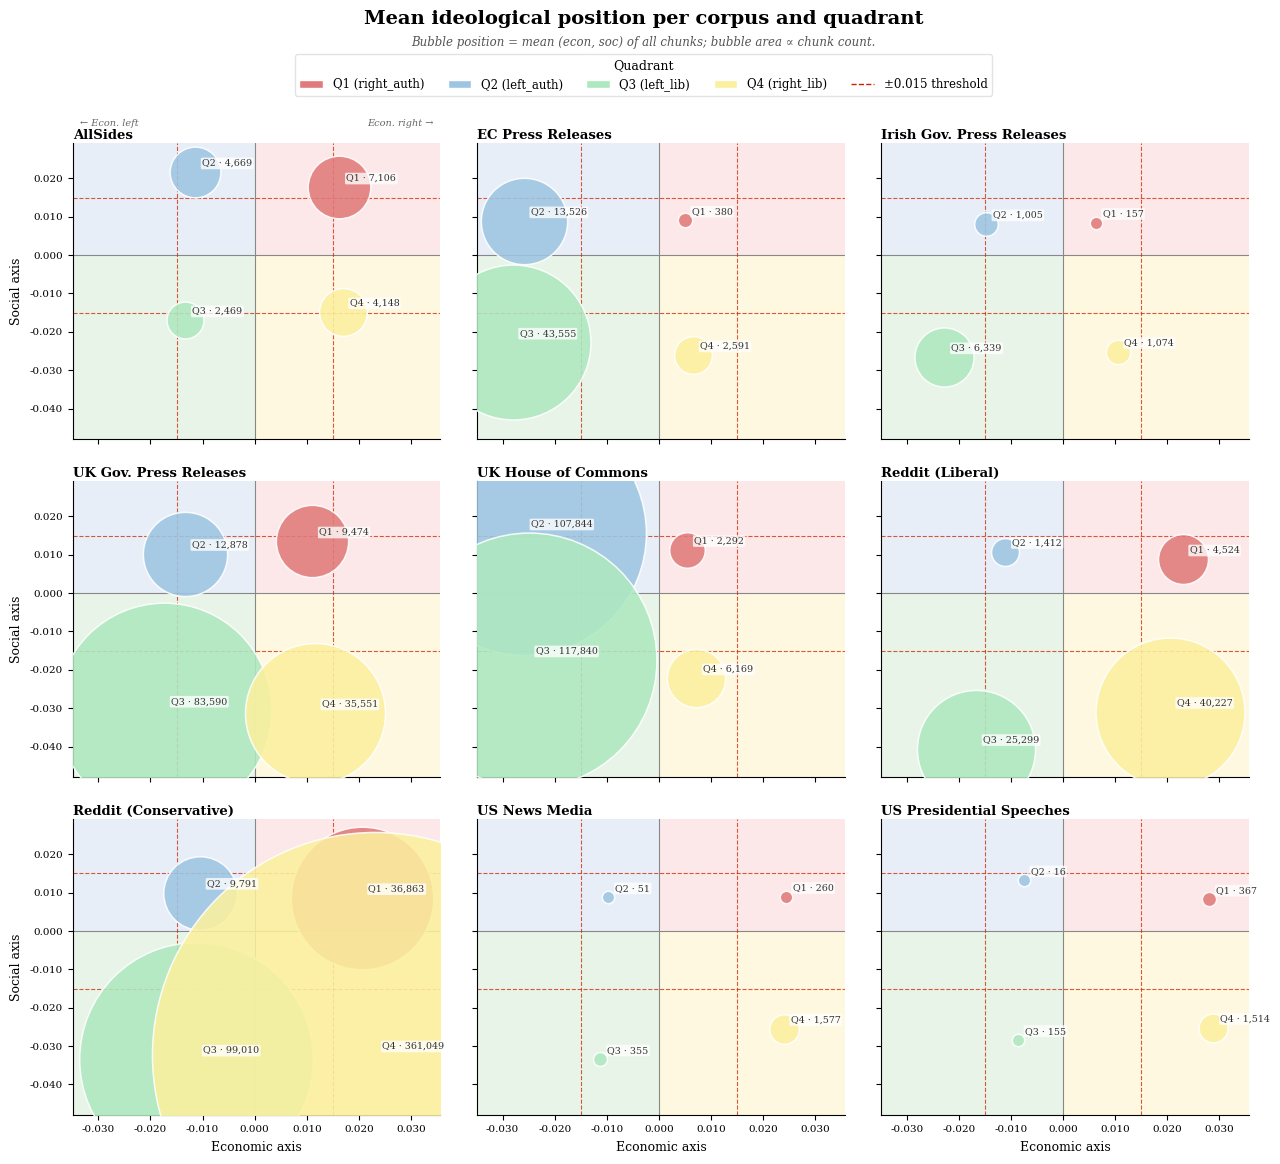

In [3]:
THRESH    = 0.015
SIZE_SCALE = 3500

x_all = df["mean_econ"].to_numpy()
y_all = df["mean_soc"].to_numpy()
x_pad = max((x_all.max() - x_all.min()) * 0.12, 0.003)
y_pad = max((y_all.max() - y_all.min()) * 0.12, 0.003)
xlim  = (x_all.min() - x_pad, x_all.max() + x_pad)
ylim  = (y_all.min() - y_pad, y_all.max() + y_pad)

# 3 × 3 grid
fig, axes = plt.subplots(3, 3, figsize=(13, 11), sharex=True, sharey=True)
axes_flat = axes.flatten()

for ax, source in zip(axes_flat, SOURCES):
    sub = df[df["source"] == source].copy()
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()

    # quadrant background — standard political compass convention
    ax.add_patch(mpatches.Rectangle(( 0,  0),  x1,  y1, facecolor="#fce8e8", edgecolor="none", zorder=0))  # Q1 right_auth — red
    ax.add_patch(mpatches.Rectangle((x0,  0), -x0,  y1, facecolor="#e8eef8", edgecolor="none", zorder=0))  # Q2 left_auth  — blue
    ax.add_patch(mpatches.Rectangle((x0, y0), -x0, -y0, facecolor="#e8f4e8", edgecolor="none", zorder=0))  # Q3 left_lib   — green
    ax.add_patch(mpatches.Rectangle(( 0, y0),  x1, -y0, facecolor="#fef8e0", edgecolor="none", zorder=0))  # Q4 right_lib  — yellow

    # axis lines
    ax.axhline(0, color="#888", lw=0.8, zorder=1)
    ax.axvline(0, color="#888", lw=0.8, zorder=1)

    # ±0.015 confidence-margin threshold lines
    for t in [THRESH, -THRESH]:
        ax.axvline(t, color="#cc2200", lw=0.8, ls="--", zorder=2, alpha=0.75)
        ax.axhline(t, color="#cc2200", lw=0.8, ls="--", zorder=2, alpha=0.75)

    # bubbles
    for _, row in sub.iterrows():
        q = row["quadrant"]
        ax.scatter(row["mean_econ"], row["mean_soc"],
                   s=max(row["n_chunks"] / SIZE_SCALE * 1000, 80),
                   color=COLORS[q], alpha=0.88, edgecolors="white", linewidths=1.1, zorder=3)
        ax.annotate(f"{Q_SHORT[q]} · {int(row['n_chunks']):,}",
                    xy=(row["mean_econ"], row["mean_soc"]),
                    xytext=(5, 3), textcoords="offset points",
                    fontsize=6.8, ha="left", va="bottom", color="#333",
                    bbox=dict(boxstyle="round,pad=0.14", fc="white", ec="none", alpha=0.78), zorder=4)

    ax.set_title(SOURCE_LABEL[source], fontsize=9.5, fontweight="bold", loc="left", pad=3)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
    ax.tick_params(labelsize=7.5)

# shared axis labels on outer edges only
for ax in axes[:, 0]:
    ax.set_ylabel("Social axis", fontsize=9, labelpad=5)
for ax in axes[-1, :]:
    ax.set_xlabel("Economic axis", fontsize=9, labelpad=5)

# directional annotations on the top-left panel
ax0 = axes[0, 0]
ax0.text(0.02, 1.06, "← Econ. left",  transform=ax0.transAxes, fontsize=7, color="#666", ha="left",  style="italic")
ax0.text(0.98, 1.06, "Econ. right →", transform=ax0.transAxes, fontsize=7, color="#666", ha="right", style="italic")

# legend
legend_handles = [mpatches.Patch(facecolor=COLORS[q], edgecolor="white", label=Q_LABEL[q]) for q in QUADRANTS]
thresh_handle  = mlines.Line2D([], [], color="#cc2200", ls="--", lw=1, label=f"±{THRESH} threshold")
fig.legend(handles=legend_handles + [thresh_handle],
           title="Quadrant", loc="upper center", ncol=5,
           bbox_to_anchor=(0.5, 1.02), fontsize=8.5, title_fontsize=9,
           frameon=True, edgecolor="#dddddd")

fig.suptitle("Mean ideological position per corpus and quadrant",
             fontsize=14, fontweight="bold", y=1.055)
fig.text(0.5, 1.022, "Bubble position = mean (econ, soc) of all chunks; bubble area ∝ chunk count.",
         ha="center", fontsize=8.5, color="#555", style="italic")

plt.tight_layout(h_pad=1.5, w_pad=1.0)
# plt.savefig("../data/experts/quadrant-pools/mean_scores_by_source.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Political compass — chunk scatter + KDE by source family

Each point is one sampled chunk at its raw (score_econ, score_soc) position.
KDE contours show the density peak per family: **Reddit** (red circles), **Press** (green squares), **Speeches** (blue triangles).

In [4]:
random.seed(0)
N_PER_SOURCE = 8_000
compass_points = {fam: {"econ": [], "soc": []} for fam in FAMILY_STYLE}

for source, family in FAMILY.items():
    path = BASE / source / "scored_chunks.jsonl"
    if not path.exists():
        print(f"[skip] {source}: scored_chunks.jsonl not found (batch not yet run?)")
        continue
    with open(path) as f:
        lines = f.readlines()
    sample = random.sample(lines, min(N_PER_SOURCE, len(lines)))
    for line in sample:
        d = json.loads(line)
        e, s = d["score_econ"], d["score_soc"]
        if e == e and s == s:
            compass_points[family]["econ"].append(e)
            compass_points[family]["soc"].append(s)

for fam, pts in compass_points.items():
    print(f"  {fam}: {len(pts['econ']):,} points")

  Reddit: 16,000 points
  Press: 34,243 points
  Speeches: 10,052 points


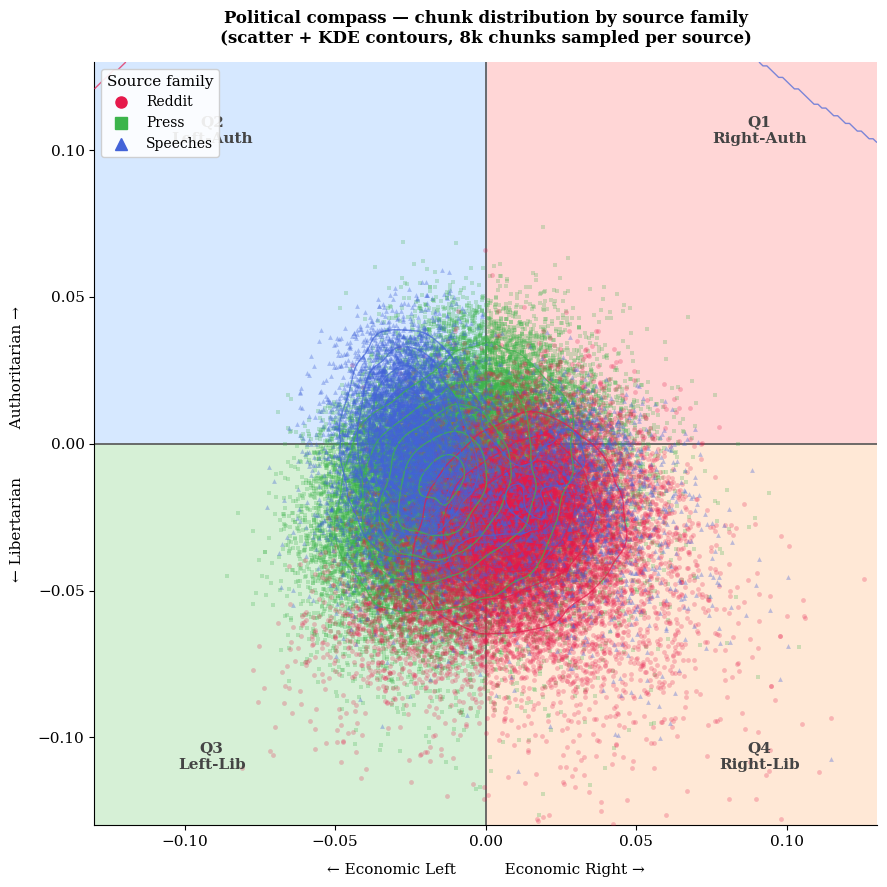

In [5]:
lim = 0.13
fig, ax = plt.subplots(figsize=(9, 9))

ax.axhspan( 0,    lim,  xmin=0.5, xmax=1,   color="#ffd6d6", zorder=0)  # Q1
ax.axhspan( 0,    lim,  xmin=0,   xmax=0.5, color="#d6e8ff", zorder=0)  # Q2
ax.axhspan(-lim,  0,    xmin=0,   xmax=0.5, color="#d6f0d6", zorder=0)  # Q3
ax.axhspan(-lim,  0,    xmin=0.5, xmax=1,   color="#ffe8d6", zorder=0)  # Q4
ax.axhline(0, color="#555", lw=1.2, zorder=1)
ax.axvline(0, color="#555", lw=1.2, zorder=1)

for fam, style in FAMILY_STYLE.items():
    pts = compass_points[fam]
    ax.scatter(pts["econ"], pts["soc"],
               c=style["color"], marker=style["marker"],
               alpha=style["alpha"], s=12, linewidths=0, zorder=style["zorder"])

grid_x = np.linspace(-lim, lim, 200)
grid_y = np.linspace(-lim, lim, 200)
xx, yy = np.meshgrid(grid_x, grid_y)
grid_coords = np.vstack([xx.ravel(), yy.ravel()])

for fam, style in FAMILY_STYLE.items():
    pts = compass_points[fam]
    if len(pts["econ"]) < 100:
        continue
    kde = gaussian_kde(np.vstack([pts["econ"], pts["soc"]]), bw_method=0.15)
    zz  = kde(grid_coords).reshape(xx.shape)
    ax.contour(xx, yy, zz, levels=5, colors=style["color"], linewidths=1.0, alpha=0.7, zorder=5)

kw = dict(fontsize=11, fontweight="bold", color="#444", va="center", ha="center")
ax.text( lim * 0.7,  lim * 0.82, "Q1\nRight-Auth", **kw)
ax.text(-lim * 0.7,  lim * 0.82, "Q2\nLeft-Auth",  **kw)
ax.text(-lim * 0.7, -lim * 0.82, "Q3\nLeft-Lib",   **kw)
ax.text( lim * 0.7, -lim * 0.82, "Q4\nRight-Lib",  **kw)

ax.set_xlabel("← Economic Left          Economic Right →", fontsize=11, labelpad=10)
ax.set_ylabel("← Libertarian          Authoritarian →",   fontsize=11, labelpad=10)
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)

handles = [
    mlines.Line2D([], [], color=st["color"], marker=st["marker"],
                  linestyle="None", markersize=8, label=fam)
    for fam, st in FAMILY_STYLE.items()
]
ax.legend(handles=handles, title="Source family", fontsize=10, loc="upper left", framealpha=0.9)
ax.set_title(
    "Political compass — chunk distribution by source family\n"
    "(scatter + KDE contours, 8k chunks sampled per source)",
    fontsize=12, fontweight="bold", pad=14,
)
plt.tight_layout()
# plt.savefig("../data/experts/quadrant-pools/political_compass.png", dpi=150, bbox_inches="tight")
plt.show()

# Phase A — Manual analysis

**Goal:** decide the viable topic set, the target N per quadrant, and the source cap.

**Inputs:** `retained.jsonl` in `quadrant-pools/<source>/<quadrant>/`, filtered at `conf_margin ≥ 0.015`, with `topic_primary` labels.

**Decisions to make:**
1. Which topics are well-represented across all four quadrants?
2. Which sources dominate individual cells → need capping or oversampling?
3. What is the confidence margin profile per cell?
4. Qualitative sanity-check: do retained texts actually sound like the intended quadrant?

In [6]:
TOPICS = [
    "economy", "immigration", "foreign_policy", "law_order",
    "environment_energy", "culture_identity", "welfare_labor",
    "health_education", "governance_institutions",
]
Q_ORDER = ["right_auth", "left_auth", "left_lib", "right_lib"]
Q_SHORT2 = {"right_auth": "Q1\nright_auth", "left_auth": "Q2\nleft_auth",
            "left_lib": "Q3\nleft_lib",     "right_lib": "Q4\nright_lib"}
SOURCES_LIST = SOURCES
SOURCE_COLORS = ["#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4", "#42d4f4", "#f032e6", "#bfef45", "#fabebe"]

rows = []
for source in SOURCES:
    for quadrant in QUADRANTS:
        path = BASE / source / quadrant / "retained.jsonl"
        if not path.exists():
            continue
        with open(path) as f:
            for line in f:
                d = json.loads(line)
                rows.append({
                    "source":            source,
                    "quadrant":          quadrant,
                    "topic_primary":     d.get("topic_primary"),
                    "confidence_margin": d.get("confidence_margin"),
                    "score_econ":        d.get("score_econ"),
                    "score_soc":         d.get("score_soc"),
                    "text":              d.get("text", ""),
                })

df_ret = pd.DataFrame(rows)
print(f"Total retained: {len(df_ret):,}")
print(f"topic_primary null rate: {df_ret['topic_primary'].isna().mean():.1%}")
print()
print(df_ret.groupby(["quadrant", "source"]).size().unstack(fill_value=0)[SOURCES])

Total retained: 402,633
topic_primary null rate: 0.0%

source      allsides  ec_press  ire_press  uk_press    hoc  reddit_liberal  \
quadrant                                                                     
left_auth        948      1839         28      1058  41897             118   
left_lib         472     20966       3394     35236  44437           10678   
right_auth      1538         1          0      1262     33             573   
right_lib        747       197        242      8491    557           16874   

source      reddit_conservative  us_media  us_speeches  
quadrant                                                
left_auth                   586         4            0  
left_lib                  23079        86           19  
right_auth                 3761        29           44  
right_lib                181960       725          754  


## A.1 — Topic × quadrant count matrix

Rows = topics, columns = quadrants. Cell = retained chunk count. Log-scale colour; annotated with raw counts.
Flag cells < 500 chunks as underrepresented.

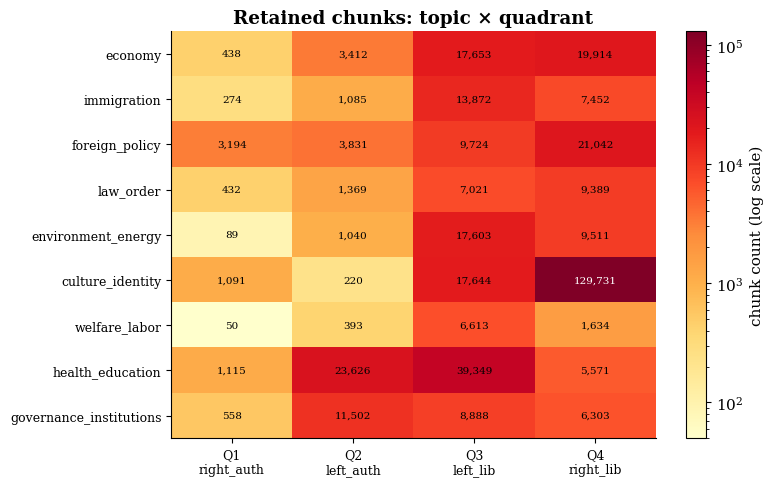

Underrepresented cells (< 500 chunks):
  economy × right_auth: 438
  immigration × right_auth: 274
  law_order × right_auth: 432
  environment_energy × right_auth: 89
  culture_identity × left_auth: 220
  welfare_labor × right_auth: 50
  welfare_labor × left_auth: 393


In [7]:
import matplotlib.colors as mcolors

pivot = (
    df_ret.groupby(["topic_primary", "quadrant"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=TOPICS, columns=Q_ORDER, fill_value=0)
)
mat = pivot.values.astype(float)
mat_plot = np.where(mat == 0, np.nan, mat)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(
    mat_plot,
    norm=mcolors.LogNorm(vmin=max(1, np.nanmin(mat_plot)), vmax=np.nanmax(mat_plot)),
    cmap="YlOrRd", aspect="auto",
)
for i in range(len(TOPICS)):
    for j in range(len(Q_ORDER)):
        v = int(mat[i, j])
        ax.text(j, i, f"{v:,}", ha="center", va="center", fontsize=7.5,
                color="white" if v > np.nanmax(mat_plot) * 0.4 else "black")
ax.set_xticks(range(len(Q_ORDER)))
ax.set_xticklabels([Q_SHORT2[q] for q in Q_ORDER], fontsize=9)
ax.set_yticks(range(len(TOPICS)))
ax.set_yticklabels(TOPICS, fontsize=9)
plt.colorbar(im, ax=ax, label="chunk count (log scale)")
ax.set_title("Retained chunks: topic × quadrant", fontweight="bold")
plt.tight_layout()
plt.show()

print("Underrepresented cells (< 500 chunks):")
for i, t in enumerate(TOPICS):
    for j, q in enumerate(Q_ORDER):
        if mat[i, j] < 500:
            print(f"  {t} × {q}: {int(mat[i,j])}")

## A.2 — Source dominance per (topic × quadrant) cell

Stacked bar: source share per quadrant. Cells where one source > 80% are flagged — risk of encoding source style rather than ideology.

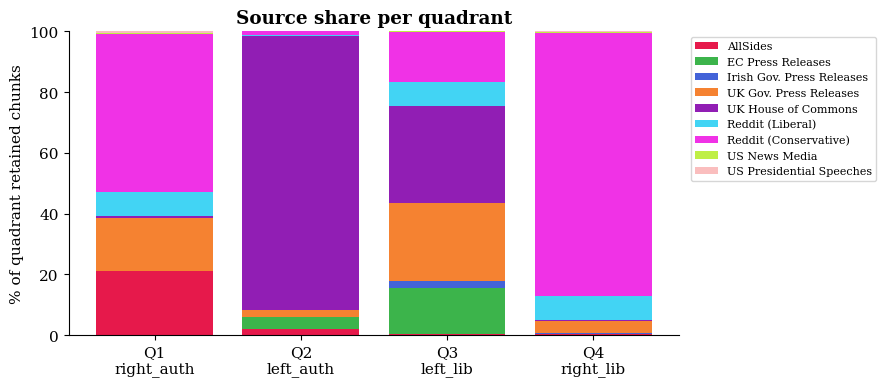


Flagged cells (one source > 80% per topic × quadrant):
          topic_primary   quadrant              source       pct
       culture_identity  right_lib reddit_conservative 92.078223
         foreign_policy  right_lib reddit_conservative 83.723030
governance_institutions  left_auth                 hoc 96.452791
governance_institutions right_auth            allsides 88.709677
       health_education  left_auth                 hoc 96.673157
       health_education right_auth            uk_press 90.224215
            immigration  right_lib reddit_conservative 81.763285
              law_order  left_auth                 hoc 91.672754
              law_order  right_lib reddit_conservative 87.772926
          welfare_labor  left_auth                 hoc 88.549618
          welfare_labor right_auth            allsides 86.000000


In [8]:
grp = df_ret.groupby(["topic_primary", "quadrant", "source"]).size().reset_index(name="n")
total = grp.groupby(["topic_primary", "quadrant"])["n"].transform("sum")
grp["pct"] = grp["n"] / total * 100

# Per-quadrant source share (aggregated over topics)
q_grp = df_ret.groupby(["quadrant", "source"]).size().unstack(fill_value=0)
q_grp = q_grp.reindex(index=Q_ORDER, columns=SOURCES_LIST, fill_value=0)
q_pct = q_grp.div(q_grp.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 4))
bottom = np.zeros(len(Q_ORDER))
for src, color in zip(SOURCES_LIST, SOURCE_COLORS):
    vals = q_pct[src].values if src in q_pct.columns else np.zeros(len(Q_ORDER))
    ax.bar([Q_SHORT2[q] for q in Q_ORDER], vals, bottom=bottom, label=SOURCE_LABEL[src], color=color)
    bottom += vals
ax.set_ylabel("% of quadrant retained chunks")
ax.set_title("Source share per quadrant", fontweight="bold")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

print("\nFlagged cells (one source > 80% per topic × quadrant):")
dominant = grp.loc[grp.groupby(["topic_primary", "quadrant"])["pct"].idxmax()]
flagged  = dominant[dominant["pct"] > 80]
print(flagged[["topic_primary", "quadrant", "source", "pct"]].to_string(index=False))

## A.3 — Confidence margin per (topic × quadrant) cell

Mean and median `conf_margin`. Darker blue = higher confidence. Low-confidence cells may warrant a higher per-cell floor.

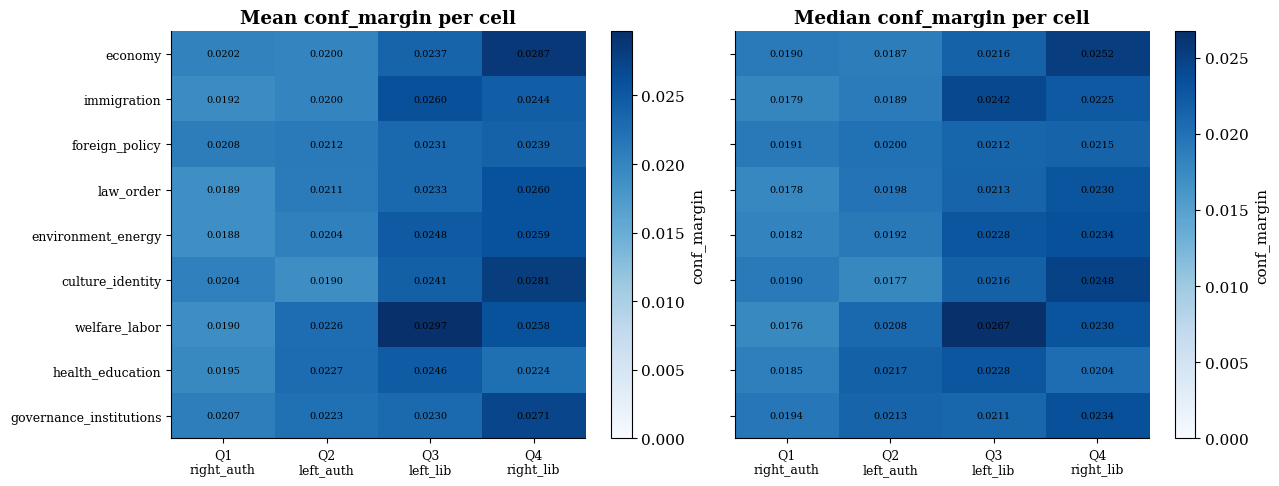

In [9]:
pivot_mean = (
    df_ret.groupby(["topic_primary", "quadrant"])["confidence_margin"]
    .mean().unstack(fill_value=0)
    .reindex(index=TOPICS, columns=Q_ORDER, fill_value=0)
)
pivot_med = (
    df_ret.groupby(["topic_primary", "quadrant"])["confidence_margin"]
    .median().unstack(fill_value=0)
    .reindex(index=TOPICS, columns=Q_ORDER, fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, piv, title in zip(axes, [pivot_mean, pivot_med], ["Mean", "Median"]):
    mat = piv.values
    im = ax.imshow(mat, cmap="Blues", vmin=0, vmax=mat.max(), aspect="auto")
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f"{mat[i,j]:.4f}", ha="center", va="center", fontsize=7)
    ax.set_xticks(range(len(Q_ORDER)))
    ax.set_xticklabels([Q_SHORT2[q] for q in Q_ORDER], fontsize=9)
    ax.set_yticks(range(len(TOPICS)))
    ax.set_yticklabels(TOPICS, fontsize=9)
    plt.colorbar(im, ax=ax, label="conf_margin")
    ax.set_title(f"{title} conf_margin per cell", fontweight="bold")
plt.tight_layout()
plt.show()

## A.4 — Sample inspection

Set `INSPECT_TOPIC` and `INSPECT_QUADRANT` to read random retained chunks from that cell.
Sanity-check: does the text belong in this quadrant? Any false positives, boilerplate, or non-English?

In [10]:
INSPECT_TOPIC    = "economy"       # set to None to skip topic filter
INSPECT_QUADRANT = "right_auth"    # right_auth | left_auth | left_lib | right_lib
N_SAMPLES        = 5

mask = df_ret["quadrant"] == INSPECT_QUADRANT
if INSPECT_TOPIC is not None:
    mask &= df_ret["topic_primary"] == INSPECT_TOPIC

pool  = df_ret[mask].reset_index(drop=True)
label = f"{INSPECT_TOPIC} × {INSPECT_QUADRANT}" if INSPECT_TOPIC else INSPECT_QUADRANT
print(f"Cell: {label}  |  retained: {len(pool):,}")
print("=" * 72)

for i, idx in enumerate(random.sample(range(len(pool)), min(N_SAMPLES, len(pool))), 1):
    row = pool.iloc[idx]
    print(f"\n--- {i} | source={row.source} | conf={row.confidence_margin:.4f}")
    print(row["text"][:600])

Cell: economy × right_auth  |  retained: 438

--- 1 | source=reddit_conservative | conf=0.0246
Source: AP Photo/Jacquelyn Martin President Trump lashed out against former House Speaker Paul Ryan on Thursday, calling him a “failed” vice presidential candidate whose record in the lower chamber was “atrocious.” “Paul Ryan, the failed V.P. candidate & former Speaker of the House, whose record of achievement was atrocious (except during my first two years as President), ultimately became a long running lame duck failure, leaving his Party in the lurch both as a fundraiser & leader,” Trump tweeted. “When Mitt chose Paul I told people that’s the end of that Presidential run. He quit Congress b

--- 2 | source=reddit_conservative | conf=0.0179
the United States during the ten-year period ending in 1940 averaged less than 10 percent of total production, while, during the 1920s, they averaged more than 25 percent. The decline in the export trade has left a large surplus in production which, in c

# Paper-Ready Figures

Clean, publication-quality versions of the key dataset figures.
White background, serif font, standard matplotlib only.
Quadrant colours follow the political compass convention used throughout this project.

In [11]:
# ── Paper style ───────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
import json
from pathlib import Path
from collections import defaultdict

plt.rcParams.update({
    "font.family":        "serif",
    "font.size":          11,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.facecolor":     "white",
    "figure.facecolor":   "white",
    "axes.edgecolor":     "#333333",
    "axes.linewidth":     0.8,
    "xtick.direction":    "out",
    "ytick.direction":    "out",
    "xtick.major.size":   3,
    "ytick.major.size":   3,
})

# Quadrant colours — political compass convention
Q_COLORS = {
    "right_auth": "#e17a7a",   # red   (Q1, top-right)
    "left_auth":  "#9dc5e2",   # blue  (Q2, top-left)
    "left_lib":   "#aee8bf",   # green (Q3, bottom-left)
    "right_lib":  "#fbf09e",   # yellow(Q4, bottom-right)
}
Q_ORDER  = ["right_auth", "left_auth", "left_lib", "right_lib"]
Q_LABELS = ["Q1\nRight-Auth", "Q2\nLeft-Auth", "Q3\nLeft-Lib", "Q4\nRight-Lib"]

# Source-family colours (for stacked bars)
FAM_COLORS = {"Reddit": "#d94f4f", "Press": "#4aaa6e", "Speeches": "#4b7bbf"}
FAMILY = {
    "reddit_liberal":      "Reddit",
    "reddit_conservative": "Reddit",
    "allsides":            "Press",
    "ec_press":            "Press",
    "ire_press":           "Press",
    "uk_press":            "Press",
    "us_media":            "Press",
    "hoc":                 "Speeches",
    "us_speeches":         "Speeches",
}

TV_BASE = Path("../data/experts/train-validate")
TOPICS  = [
    "economy", "immigration", "foreign_policy", "law_order",
    "environment_energy", "culture_identity", "welfare_labor",
    "health_education", "governance_institutions",
]

print("Paper style loaded.")

Paper style loaded.


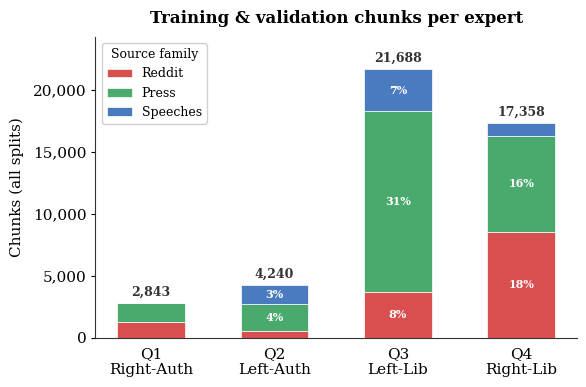

In [12]:
# ── Figure A.1: Training & validation chunks per expert by source family ───────
# Replicates the bar chart in the appendix on a white background.

fam_counts = {q: defaultdict(int) for q in Q_ORDER}
split_totals = {q: {"train": 0, "val": 0} for q in Q_ORDER}

for quadrant in Q_ORDER:
    for split in ("train.jsonl", "val_indist.jsonl", "val_source.jsonl", "val_topic.jsonl"):
        path = TV_BASE / quadrant / split
        if not path.exists():
            continue
        is_train = split == "train.jsonl"
        with open(path) as f:
            for line in f:
                d = json.loads(line)
                src = d.get("source", "")
                fam = FAMILY.get(src, "Press")
                fam_counts[quadrant][fam] += 1
                if is_train:
                    split_totals[quadrant]["train"] += 1
                else:
                    split_totals[quadrant]["val"] += 1

families = ["Reddit", "Press", "Speeches"]
totals   = [sum(fam_counts[q].values()) for q in Q_ORDER]

fig, ax = plt.subplots(figsize=(6, 4))

bottoms = np.zeros(len(Q_ORDER))
for fam in families:
    vals = np.array([fam_counts[q][fam] for q in Q_ORDER], dtype=float)
    bars = ax.bar(
        Q_LABELS, vals, bottom=bottoms,
        color=FAM_COLORS[fam], label=fam,
        edgecolor="white", linewidth=0.5, width=0.55,
    )
    # label segments that are large enough to read
    for bar, v, b in zip(bars, vals, bottoms):
        if v / max(totals) > 0.07:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                b + v / 2,
                f"{int(v / sum(totals) * 100)}%",
                ha="center", va="center", fontsize=8, color="white", fontweight="bold",
            )
    bottoms += vals

# total annotations above each bar
for i, (total, x_label) in enumerate(zip(totals, Q_LABELS)):
    ax.text(i, total + max(totals) * 0.015, f"{total:,}",
            ha="center", va="bottom", fontsize=9, fontweight="bold", color="#333")

ax.set_ylabel("Chunks (all splits)", labelpad=6)
ax.set_ylim(0, max(totals) * 1.12)
ax.set_title("Training & validation chunks per expert", fontsize=12, fontweight="bold", pad=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.tick_params(axis="x", bottom=False)
ax.legend(title="Source family", fontsize=9, title_fontsize=9,
          loc="upper left", frameon=True, framealpha=0.9, edgecolor="#cccccc")

plt.tight_layout()
plt.savefig("../docs/fig_A1_chunks_per_expert.pdf", dpi=300, bbox_inches="tight")
plt.show()

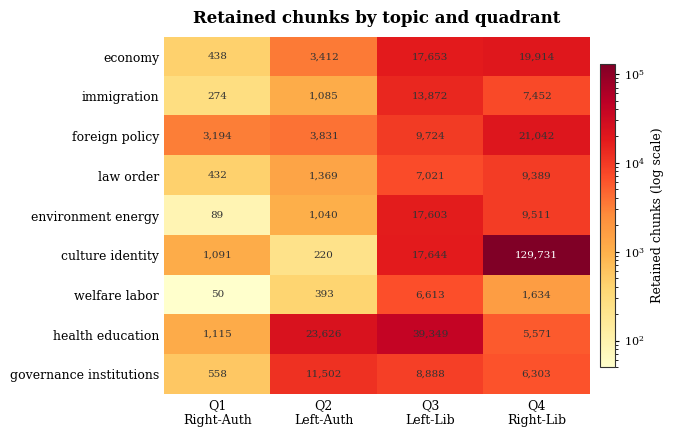

In [13]:
# ── Figure A.2: Retained chunks by topic × quadrant (heatmap) ─────────────────

import pandas as pd

# reuse df_ret from Phase A if still in scope; otherwise reload
try:
    _ = df_ret
except NameError:
    rows = []
    BASE_POOLS = Path("../data/experts/quadrant-pools")
    for source in ["allsides","ec_press","ire_press","uk_press","hoc",
                   "reddit_liberal","reddit_conservative","us_media","us_speeches"]:
        for quadrant in Q_ORDER:
            path = BASE_POOLS / source / quadrant / "retained.jsonl"
            if not path.exists():
                continue
            with open(path) as f:
                for line in f:
                    d = json.loads(line)
                    rows.append({"quadrant": quadrant,
                                 "topic_primary": d.get("topic_primary")})
    df_ret = pd.DataFrame(rows)

pivot = (
    df_ret.groupby(["topic_primary", "quadrant"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=TOPICS, columns=Q_ORDER, fill_value=0)
)
mat = pivot.values.astype(float)

fig, ax = plt.subplots(figsize=(7, 4.5))

im = ax.imshow(
    np.where(mat == 0, np.nan, mat),
    norm=mcolors.LogNorm(vmin=max(1, np.nanmin(mat[mat > 0])), vmax=mat.max()),
    cmap="YlOrRd", aspect="auto",
)

for i in range(len(TOPICS)):
    for j in range(len(Q_ORDER)):
        v = int(mat[i, j])
        text_color = "white" if mat[i, j] > mat.max() * 0.35 else "#333"
        ax.text(j, i, f"{v:,}", ha="center", va="center",
                fontsize=7.5, color=text_color)

ax.set_xticks(range(len(Q_ORDER)))
ax.set_xticklabels(Q_LABELS, fontsize=9)
ax.set_yticks(range(len(TOPICS)))
ax.set_yticklabels([t.replace("_", " ") for t in TOPICS], fontsize=9)

cbar = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
cbar.set_label("Retained chunks (log scale)", fontsize=9)
cbar.ax.tick_params(labelsize=8)

ax.set_title("Retained chunks by topic and quadrant", fontsize=12, fontweight="bold", pad=10)
ax.tick_params(axis="both", which="both", length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("../docs/fig_A2_topic_quadrant_heatmap.pdf", dpi=300, bbox_inches="tight")
plt.show()

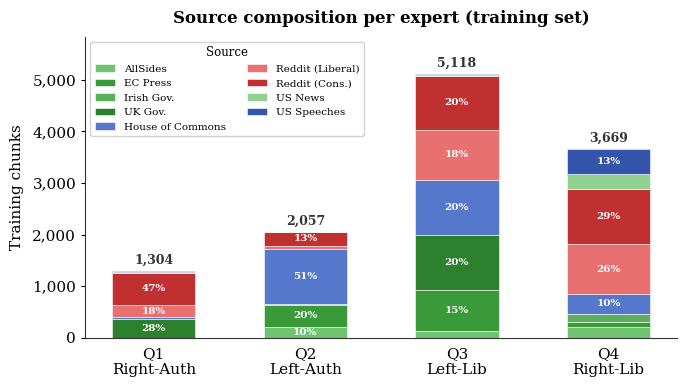

In [14]:
# ── Figure A.3: Source composition per quadrant (training set only) ────────────

SOURCE_LABEL = {
    "allsides":            "AllSides",
    "ec_press":            "EC Press",
    "ire_press":           "Irish Gov.",
    "uk_press":            "UK Gov.",
    "hoc":                 "House of Commons",
    "reddit_liberal":      "Reddit (Liberal)",
    "reddit_conservative": "Reddit (Cons.)",
    "us_media":            "US News",
    "us_speeches":         "US Speeches",
}
SOURCES_ORDER = list(SOURCE_LABEL.keys())

# Source colours: group by family with graduated shades
SRC_COLORS = {
    "reddit_liberal":      "#e87070",
    "reddit_conservative": "#c03030",
    "allsides":            "#70c470",
    "ec_press":            "#3a9a3a",
    "ire_press":           "#5ab05a",
    "uk_press":            "#2d802d",
    "us_media":            "#90d090",
    "hoc":                 "#5577cc",
    "us_speeches":         "#3355aa",
}

# Count training chunks per (quadrant, source)
train_src = {q: defaultdict(int) for q in Q_ORDER}
for quadrant in Q_ORDER:
    path = TV_BASE / quadrant / "train.jsonl"
    if not path.exists():
        continue
    with open(path) as f:
        for line in f:
            src = json.loads(line).get("source", "")
            train_src[quadrant][src] += 1

train_totals = [sum(train_src[q].values()) for q in Q_ORDER]

fig, ax = plt.subplots(figsize=(7, 4))

bottoms = np.zeros(len(Q_ORDER))
for src in SOURCES_ORDER:
    vals = np.array([train_src[q].get(src, 0) for q in Q_ORDER], dtype=float)
    if vals.sum() == 0:
        continue
    bars = ax.bar(
        Q_LABELS, vals, bottom=bottoms,
        color=SRC_COLORS[src], label=SOURCE_LABEL[src],
        edgecolor="white", linewidth=0.4, width=0.55,
    )
    for bar, v, b, total in zip(bars, vals, bottoms, train_totals):
        if total > 0 and v / total > 0.09:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                b + v / 2,
                f"{int(v / total * 100)}%",
                ha="center", va="center", fontsize=7.5, color="white", fontweight="bold",
            )
    bottoms += vals

for i, total in enumerate(train_totals):
    ax.text(i, total + max(train_totals) * 0.015, f"{total:,}",
            ha="center", va="bottom", fontsize=9, fontweight="bold", color="#333")

ax.set_ylabel("Training chunks", labelpad=6)
ax.set_ylim(0, max(train_totals) * 1.14)
ax.set_title("Source composition per expert (training set)", fontsize=12, fontweight="bold", pad=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.tick_params(axis="x", bottom=False)
ax.legend(title="Source", fontsize=7.5, title_fontsize=8.5, ncol=2,
          loc="upper left", frameon=True, framealpha=0.9, edgecolor="#cccccc")

plt.tight_layout()
plt.savefig("../docs/fig_A3_source_composition.pdf", dpi=300, bbox_inches="tight")
plt.show()

---
## Figure B.1 — Political compass projection of retained chunks (by quadrant)

Each point is one sampled retained chunk at its steering-vector projection coordinates.
Red dashed lines at ±0.015 show the confidence-margin threshold used to filter out centrist chunks.

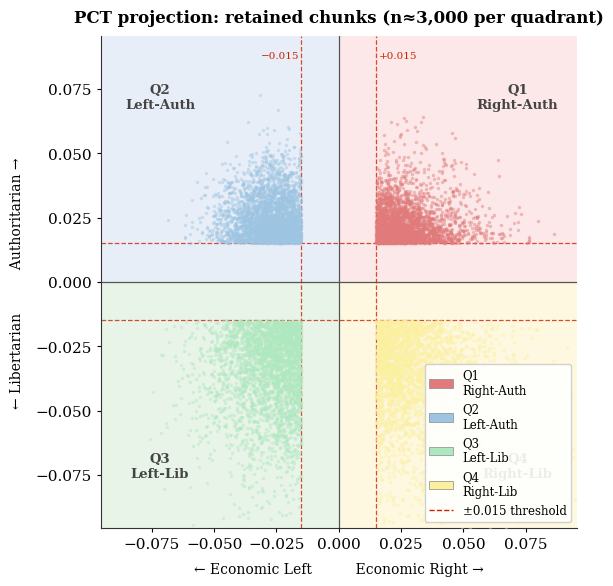

In [15]:
# ── Figure B.1: PCT projection — retained chunks coloured by quadrant ──────────

import random
import matplotlib.lines as mlines

random.seed(42)
N_SAMPLE = 3_000
THRESH   = 0.015

# correct political compass background tints
QUAD_BG_B1 = {
    "right_auth": "#fce8e8",   # red   tint — top-right
    "left_auth":  "#e8eef8",   # blue  tint — top-left
    "left_lib":   "#e8f4e8",   # green tint — bottom-left
    "right_lib":  "#fef8e0",   # yellow tint — bottom-right
}

# sample from df_ret (loaded in Phase A)
sample_rows = []
for q in Q_ORDER:
    sub = df_ret[df_ret["quadrant"] == q]
    sample_rows.append(sub.sample(min(N_SAMPLE, len(sub)), random_state=42))
df_sample = pd.concat(sample_rows, ignore_index=True)

# axis limits: 99.5th percentile of absolute scores, at least 3× threshold
lim = max(
    df_sample[["score_econ", "score_soc"]].abs().quantile(0.995).max() * 1.05,
    THRESH * 3,
)

fig, ax = plt.subplots(figsize=(6, 6))

# quadrant background
ax.add_patch(mpatches.Rectangle(( 0,  0),  lim,  lim, facecolor=QUAD_BG_B1["right_auth"], edgecolor="none", zorder=0))
ax.add_patch(mpatches.Rectangle((-lim, 0),  lim,  lim, facecolor=QUAD_BG_B1["left_auth"],  edgecolor="none", zorder=0))
ax.add_patch(mpatches.Rectangle((-lim,-lim), lim,  lim, facecolor=QUAD_BG_B1["left_lib"],  edgecolor="none", zorder=0))
ax.add_patch(mpatches.Rectangle(( 0, -lim), lim,  lim, facecolor=QUAD_BG_B1["right_lib"], edgecolor="none", zorder=0))

ax.axhline(0, color="#555", lw=0.9, zorder=1)
ax.axvline(0, color="#555", lw=0.9, zorder=1)

# ±0.015 threshold lines
for t in [THRESH, -THRESH]:
    ax.axvline(t, color="#cc2200", lw=0.9, ls="--", zorder=2, alpha=0.8)
    ax.axhline(t, color="#cc2200", lw=0.9, ls="--", zorder=2, alpha=0.8)

# scatter per quadrant
for q, lbl in zip(Q_ORDER, Q_LABELS):
    sub = df_sample[df_sample["quadrant"] == q]
    ax.scatter(sub["score_econ"], sub["score_soc"],
               c=Q_COLORS[q], s=6, alpha=0.45, linewidths=0, zorder=3, label=lbl)

# quadrant corner labels
kw_lbl = dict(fontsize=9.5, fontweight="bold", color="#444", ha="center", va="center")
pad = lim * 0.75
ax.text( pad,  pad, "Q1\nRight-Auth", **kw_lbl)
ax.text(-pad,  pad, "Q2\nLeft-Auth",  **kw_lbl)
ax.text(-pad, -pad, "Q3\nLeft-Lib",   **kw_lbl)
ax.text( pad, -pad, "Q4\nRight-Lib",  **kw_lbl)

# threshold value annotations
ax.text(THRESH + lim * 0.01,  lim * 0.94, f"+{THRESH}", color="#cc2200",
        fontsize=7.5, ha="left", va="top")
ax.text(-THRESH - lim * 0.01, lim * 0.94, f"−{THRESH}", color="#cc2200",
        fontsize=7.5, ha="right", va="top")

ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel("← Economic Left          Economic Right →", fontsize=10, labelpad=8)
ax.set_ylabel("← Libertarian          Authoritarian →",   fontsize=10, labelpad=8)
ax.set_title(f"PCT projection: retained chunks (n≈{N_SAMPLE:,} per quadrant)",
             fontsize=12, fontweight="bold", pad=10)

q_handles  = [mpatches.Patch(facecolor=Q_COLORS[q], edgecolor="#888", linewidth=0.5, label=lbl)
              for q, lbl in zip(Q_ORDER, Q_LABELS)]
thr_handle = mlines.Line2D([], [], color="#cc2200", ls="--", lw=1, label=f"±{THRESH} threshold")
ax.legend(handles=q_handles + [thr_handle], fontsize=8.5,
          loc="lower right", frameon=True, framealpha=0.9, edgecolor="#cccccc")

plt.tight_layout()
plt.savefig("../docs/fig_B1_pct_projection.pdf", dpi=300, bbox_inches="tight")
plt.show()

---
## Figure B.2 — Dataset split sizes per expert

Each expert has four splits: **train**, **val (in-dist)**, **val (source)**, and **val (topic)**.
The large val-topic counts for Q3/Q4 reflect the heavy immigration content in left-lib and right-lib corpora.

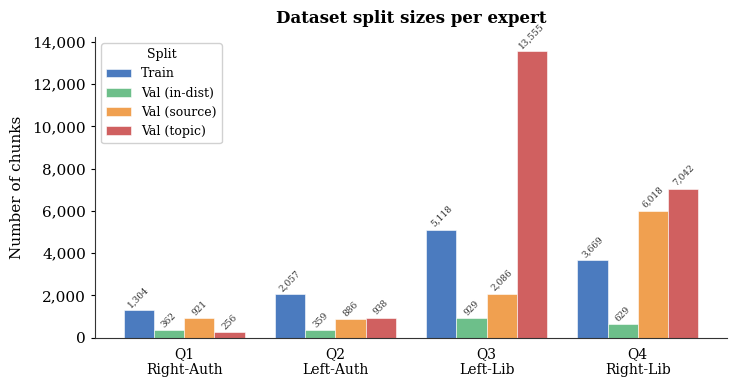

Split totals per expert:
  Q1 Right-Auth: train=1,304  val_indist=362  val_source=921  val_topic=256  → total=2,843
  Q2 Left-Auth: train=2,057  val_indist=359  val_source=886  val_topic=938  → total=4,240
  Q3 Left-Lib: train=5,118  val_indist=929  val_source=2,086  val_topic=13,555  → total=21,688
  Q4 Right-Lib: train=3,669  val_indist=629  val_source=6,018  val_topic=7,042  → total=17,358


In [16]:
# ── Figure B.2: Expert dataset split sizes ─────────────────────────────────────

SPLIT_FILES = {
    "train":      "train.jsonl",
    "val_indist": "val_indist.jsonl",
    "val_source": "val_source.jsonl",
    "val_topic":  "val_topic.jsonl",
}
SPLIT_LABELS = {
    "train":      "Train",
    "val_indist": "Val (in-dist)",
    "val_source": "Val (source)",
    "val_topic":  "Val (topic)",
}
SPLIT_COLORS = {
    "train":      "#4b7bbf",
    "val_indist": "#6dbf8a",
    "val_source": "#f0a050",
    "val_topic":  "#d06060",
}

# count rows per expert × split
split_counts = {q: {} for q in Q_ORDER}
for quadrant in Q_ORDER:
    for split_key, fname in SPLIT_FILES.items():
        path = TV_BASE / quadrant / fname
        if path.exists():
            with open(path) as f:
                split_counts[quadrant][split_key] = sum(1 for _ in f)
        else:
            split_counts[quadrant][split_key] = 0

n_splits  = len(SPLIT_FILES)
bar_width = 0.18
group_gap = 0.9
xs = np.arange(len(Q_ORDER)) * group_gap

fig, ax = plt.subplots(figsize=(7.5, 4))

for i, (split_key, split_label) in enumerate(SPLIT_LABELS.items()):
    offset = (i - (n_splits - 1) / 2) * bar_width
    vals   = [split_counts[q][split_key] for q in Q_ORDER]
    bars   = ax.bar(xs + offset, vals, width=bar_width,
                    color=SPLIT_COLORS[split_key], label=split_label,
                    edgecolor="white", linewidth=0.4)
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 50,
                    f"{v:,}", ha="center", va="bottom",
                    fontsize=6.5, color="#333", rotation=45)

ax.set_xticks(xs)
ax.set_xticklabels(Q_LABELS, fontsize=10)
ax.set_ylabel("Number of chunks", labelpad=6)
ax.set_title("Dataset split sizes per expert", fontsize=12, fontweight="bold", pad=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.tick_params(axis="x", bottom=False)
ax.legend(title="Split", fontsize=9, title_fontsize=9,
          loc="upper left", frameon=True, framealpha=0.9, edgecolor="#cccccc")

plt.tight_layout()
plt.savefig("../docs/fig_B2_split_sizes.pdf", dpi=300, bbox_inches="tight")
plt.show()

# print totals for reference
print("Split totals per expert:")
for q, lbl in zip(Q_ORDER, Q_LABELS):
    parts = "  ".join(f"{k}={split_counts[q][k]:,}" for k in SPLIT_FILES)
    total = sum(split_counts[q].values())
    print(f"  {lbl.replace(chr(10),' ')}: {parts}  → total={total:,}")

---
## Figure B.3 — Political compass: chunk distribution by source family

Scatter + KDE contours for all retained chunks, coloured by source family (Reddit / Press / Speeches).
Red dashed lines at ±0.015 mark the confidence-margin threshold. Quadrant background tints follow the standard political compass convention.

Using cached compass_points.


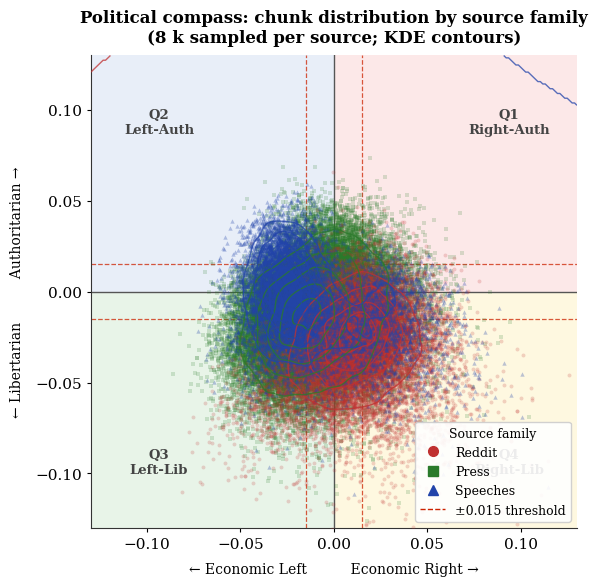

In [17]:
# ── Figure B.3: Political compass — chunk distribution by source family ─────────
# Paper-ready redo: white background, correct quadrant tints, ±0.015 threshold lines.

import matplotlib.lines as mlines
from scipy.stats import gaussian_kde

THRESH = 0.015
FAM_STYLE = {
    "Reddit":   {"color": "#c03030", "marker": "o", "alpha": 0.20, "zorder": 3, "s": 8},
    "Press":    {"color": "#2a7a2a", "marker": "s", "alpha": 0.18, "zorder": 2, "s": 8},
    "Speeches": {"color": "#2244aa", "marker": "^", "alpha": 0.30, "zorder": 4, "s": 10},
}
QUAD_BG = {
    "right_auth": "#fce8e8",   # red   tint — top-right
    "left_auth":  "#e8eef8",   # blue  tint — top-left
    "left_lib":   "#e8f4e8",   # green tint — bottom-left
    "right_lib":  "#fef8e0",   # yellow tint — bottom-right
}

# reuse compass_points from Phase 0 if still in scope
try:
    _ = compass_points
    print("Using cached compass_points.")
except NameError:
    import random
    random.seed(0)
    N_PER_SOURCE = 8_000
    BASE_POOLS   = Path("../data/experts/quadrant-pools")
    SOURCES_ALL  = ["allsides","ec_press","ire_press","uk_press","hoc",
                    "reddit_liberal","reddit_conservative","us_media","us_speeches"]
    compass_points = {fam: {"econ": [], "soc": []} for fam in FAM_STYLE}
    for src in SOURCES_ALL:
        fam  = FAMILY.get(src, "Press")
        path = BASE_POOLS / src / "scored_chunks.jsonl"
        if not path.exists():
            continue
        with open(path) as f:
            lines = f.readlines()
        sample = random.sample(lines, min(N_PER_SOURCE, len(lines)))
        for line in sample:
            d = json.loads(line)
            e, s = d["score_econ"], d["score_soc"]
            if e == e and s == s:
                compass_points[fam]["econ"].append(e)
                compass_points[fam]["soc"].append(s)

lim = 0.13
fig, ax = plt.subplots(figsize=(6, 6))

# quadrant background
ax.add_patch(mpatches.Rectangle(( 0,  0),  lim,  lim, facecolor=QUAD_BG["right_auth"], edgecolor="none", zorder=0))
ax.add_patch(mpatches.Rectangle((-lim, 0),  lim,  lim, facecolor=QUAD_BG["left_auth"],  edgecolor="none", zorder=0))
ax.add_patch(mpatches.Rectangle((-lim,-lim), lim,  lim, facecolor=QUAD_BG["left_lib"],  edgecolor="none", zorder=0))
ax.add_patch(mpatches.Rectangle(( 0, -lim), lim,  lim, facecolor=QUAD_BG["right_lib"], edgecolor="none", zorder=0))

ax.axhline(0, color="#555", lw=1.0, zorder=1)
ax.axvline(0, color="#555", lw=1.0, zorder=1)

# ±0.015 threshold lines
for t in [THRESH, -THRESH]:
    ax.axvline(t, color="#cc2200", lw=0.9, ls="--", zorder=2, alpha=0.75)
    ax.axhline(t, color="#cc2200", lw=0.9, ls="--", zorder=2, alpha=0.75)

# scatter
for fam, style in FAM_STYLE.items():
    pts = compass_points[fam]
    ax.scatter(pts["econ"], pts["soc"],
               c=style["color"], marker=style["marker"],
               alpha=style["alpha"], s=style["s"], linewidths=0, zorder=style["zorder"])

# KDE contours
grid_x = np.linspace(-lim, lim, 200)
grid_y = np.linspace(-lim, lim, 200)
xx, yy = np.meshgrid(grid_x, grid_y)
grid_coords = np.vstack([xx.ravel(), yy.ravel()])
for fam, style in FAM_STYLE.items():
    pts = compass_points[fam]
    if len(pts["econ"]) < 100:
        continue
    kde = gaussian_kde(np.vstack([pts["econ"], pts["soc"]]), bw_method=0.15)
    zz  = kde(grid_coords).reshape(xx.shape)
    ax.contour(xx, yy, zz, levels=5, colors=style["color"], linewidths=1.0, alpha=0.75, zorder=5)

kw = dict(fontsize=9.5, fontweight="bold", color="#444", ha="center", va="center")
pad = lim * 0.72
ax.text( pad,  pad, "Q1\nRight-Auth", **kw)
ax.text(-pad,  pad, "Q2\nLeft-Auth",  **kw)
ax.text(-pad, -pad, "Q3\nLeft-Lib",   **kw)
ax.text( pad, -pad, "Q4\nRight-Lib",  **kw)

ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel("← Economic Left          Economic Right →", fontsize=10, labelpad=8)
ax.set_ylabel("← Libertarian          Authoritarian →",   fontsize=10, labelpad=8)
ax.set_title("Political compass: chunk distribution by source family\n(8 k sampled per source; KDE contours)",
             fontsize=12, fontweight="bold", pad=10)

scatter_handles = [
    mlines.Line2D([], [], color=st["color"], marker=st["marker"],
                  linestyle="None", markersize=7, label=fam)
    for fam, st in FAM_STYLE.items()
]
thresh_handle = mlines.Line2D([], [], color="#cc2200", ls="--", lw=1, label=f"±{THRESH} threshold")
ax.legend(handles=scatter_handles + [thresh_handle], title="Source family",
          fontsize=9, title_fontsize=9,
          loc="lower right", frameon=True, framealpha=0.9, edgecolor="#cccccc")

plt.tight_layout()
plt.savefig("../docs/fig_B3_compass_source_family.pdf", dpi=300, bbox_inches="tight")
plt.show()